In [7]:
#Importing the libraries to be used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [8]:
gender_data = pd.read_csv('gender_classification_v7.csv')
gender_data.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [9]:
gender_data['gender'].value_counts()

gender
Female    2501
Male      2500
Name: count, dtype: int64

In [10]:
print(gender_data.isnull().sum())

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


In [11]:
# Defining the features and the target variable
X, Y = gender_data.loc[:,(gender_data.columns != 'gender')], gender_data['gender']

# splitting the data into training, validation and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.25, random_state=42)

In [12]:
# encoding the target variable
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_val = le.transform(Y_val)
Y_test = le.transform(Y_test)

In [13]:
# scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val) 
X_test = scaler.transform(X_test)

In [14]:
# creating the XGBoost classifier model
xgb_classifier = xgb.XGBClassifier(random_state=42)
# fitting the model to the training data and making predictions on the validation set
xgb_classifier.fit(X_train, Y_train)
Y_pred = xgb_classifier.predict(X_val)

# evaluating the model's performance on the validation set
val_accuracy = accuracy_score(Y_val, Y_pred)
print(f'Validation Accuracy: {val_accuracy:.4f}')

# printing the classification report and confusion matrix for the validation set
print("Classification Report:\n", classification_report(Y_val, Y_pred)) 
print("Confusion Matrix:\n", confusion_matrix(Y_val, Y_pred))

# calculating the F1 score for the validation set
f1_score = classification_report(Y_val, Y_pred, output_dict=True)['weighted avg']['f1-score']
print(f'Validation F1 Score: {f1_score:.4f}')

Validation Accuracy: 0.9770
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       495
           1       0.98      0.97      0.98       505

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Confusion Matrix:
 [[485  10]
 [ 13 492]]
Validation F1 Score: 0.9770


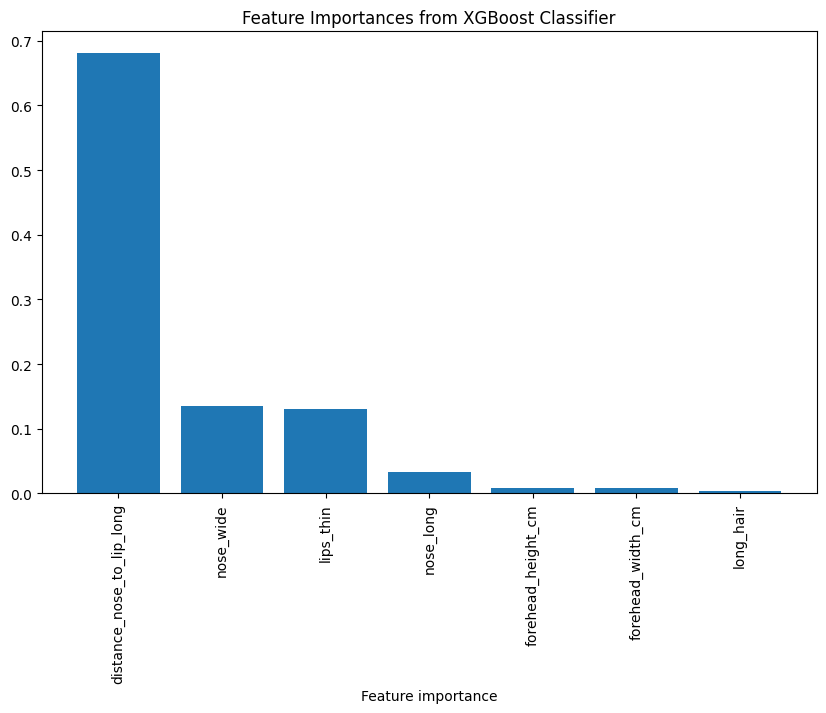

In [15]:
feature_importances = xgb_classifier.feature_importances_
feature_names = X.columns
# creating a DataFrame to display feature importances
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center')
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.title('Feature Importances from XGBoost Classifier')
plt.xlabel('Feature importance')
plt.show()


In [16]:
# Tuning the hyperparameters of the XGBoost model using RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda': [0.5, 0.7, 1, 1.5, 2]
}

xgb_model = xgb.XGBClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, n_iter=100, scoring='accuracy', cv=10, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train, Y_train)

best_xgb = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)
print("Best Accuracy Score from RandomizedSearchCV:", random_search.best_score_)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 100, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best Accuracy Score from RandomizedSearchCV: 0.9763333333333334


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [18]:
Y_pred = best_xgb.predict(X_test)

test_accuracy = accuracy_score(Y_test, Y_pred)
print(f'Test Accuracy: {test_accuracy:.4f}')

print("Classification Report:\n", classification_report(Y_test, Y_pred))

print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

print(f'Test F1 Score: {classification_report(Y_test, Y_pred, output_dict=True)["weighted avg"]["f1-score"]:.4f}')

Test Accuracy: 0.9660
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       502
           1       0.99      0.94      0.97       499

    accuracy                           0.97      1001
   macro avg       0.97      0.97      0.97      1001
weighted avg       0.97      0.97      0.97      1001

Confusion Matrix:
 [[496   6]
 [ 28 471]]
Test F1 Score: 0.9660
